# Population Coding - Algorithm

### Stephen Spivack, CDS Adjunct, Fall 2025

Import libraries

In [1]:
import os
import math
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from google.cloud import bigquery
import imageio.v2 as imageio
from tqdm import tqdm

/Users/sspivack/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Init client

In [2]:
%load_ext google.cloud.bigquery
client = bigquery.Client() 

Ingest data

In [3]:
%%bigquery motor_cortex
  select *
  from neural-ds-fe73.lab4_population_coding.motor_cortex

Query is running:   0%|          |

Downloading:   0%|          |

In [4]:
motor_cortex
#143 neurons, #158 trials

,trial_id,cell_id,brain_area,window,spike_count,direction,instruction_time,go_time
0,0,0,PMd,instruction,0.0,3,14.852567,16.308333
1,0,0,PMd,go,8.0,3,14.852567,16.308333
2,0,1,PMd,instruction,9.0,3,14.852567,16.308333
3,0,1,PMd,go,23.0,3,14.852567,16.308333
4,0,2,PMd,instruction,3.0,3,14.852567,16.308333
...,...,...,...,...,...,...,...,...
45183,157,140,MI,go,16.0,8,1310.062867,1311.268667
45184,157,141,MI,instruction,0.0,8,1310.062867,1311.268667
45185,157,141,MI,go,2.0,8,1310.062867,1311.268667
45186,157,142,MI,instruction,4.0,8,1310.062867,1311.268667


### Neural Encoding and Decoding

#### Encoding
- Neural activity (spike rate) is modeled as a function of behavior.
- Example: firing rate varies with movement direction.

#### Decoding
- Behavior is inferred from neural activity.
- Goal: **predict upcoming arm movement direction** from a *population* of motor cortex neurons.

---

### Why Population Coding?

**Limitations of single-neuron encoding:**
1. **Symmetric tuning**: Cosine-like curves → same rate for two opposite directions.
2. **Noise**: Single neurons are unreliable.

**Solution**: Combine responses across neurons — population-level decoding averages out ambiguity and noise.

---

### Population Vector Algorithm (Georgopoulos et al., 1986)

Each neuron's contribution is a vector in its preferred direction, scaled by how much its firing increases from baseline:

$$
\mathbf{P}(M) = \sum_{i=1}^{N} w_i(M) \cdot \mathbf{C}_i
$$

Where:
- $\mathbf{P}(M)$: predicted movement direction (population vector)
- $N$: number of neurons
- $\mathbf{C}_i$: unit vector in preferred direction of neuron $i$
- $w_i(M)$: activity weight = $d_i(M) - b_i$
- $d_i(M)$: firing rate during movement $M$
- $b_i$: baseline firing rate

**Simplified form:**

$$
\mathbf{P}(M) = \sum_{i=1}^{N} \left(d_i(M) - b_i\right) \cdot \mathbf{C}_i
$$


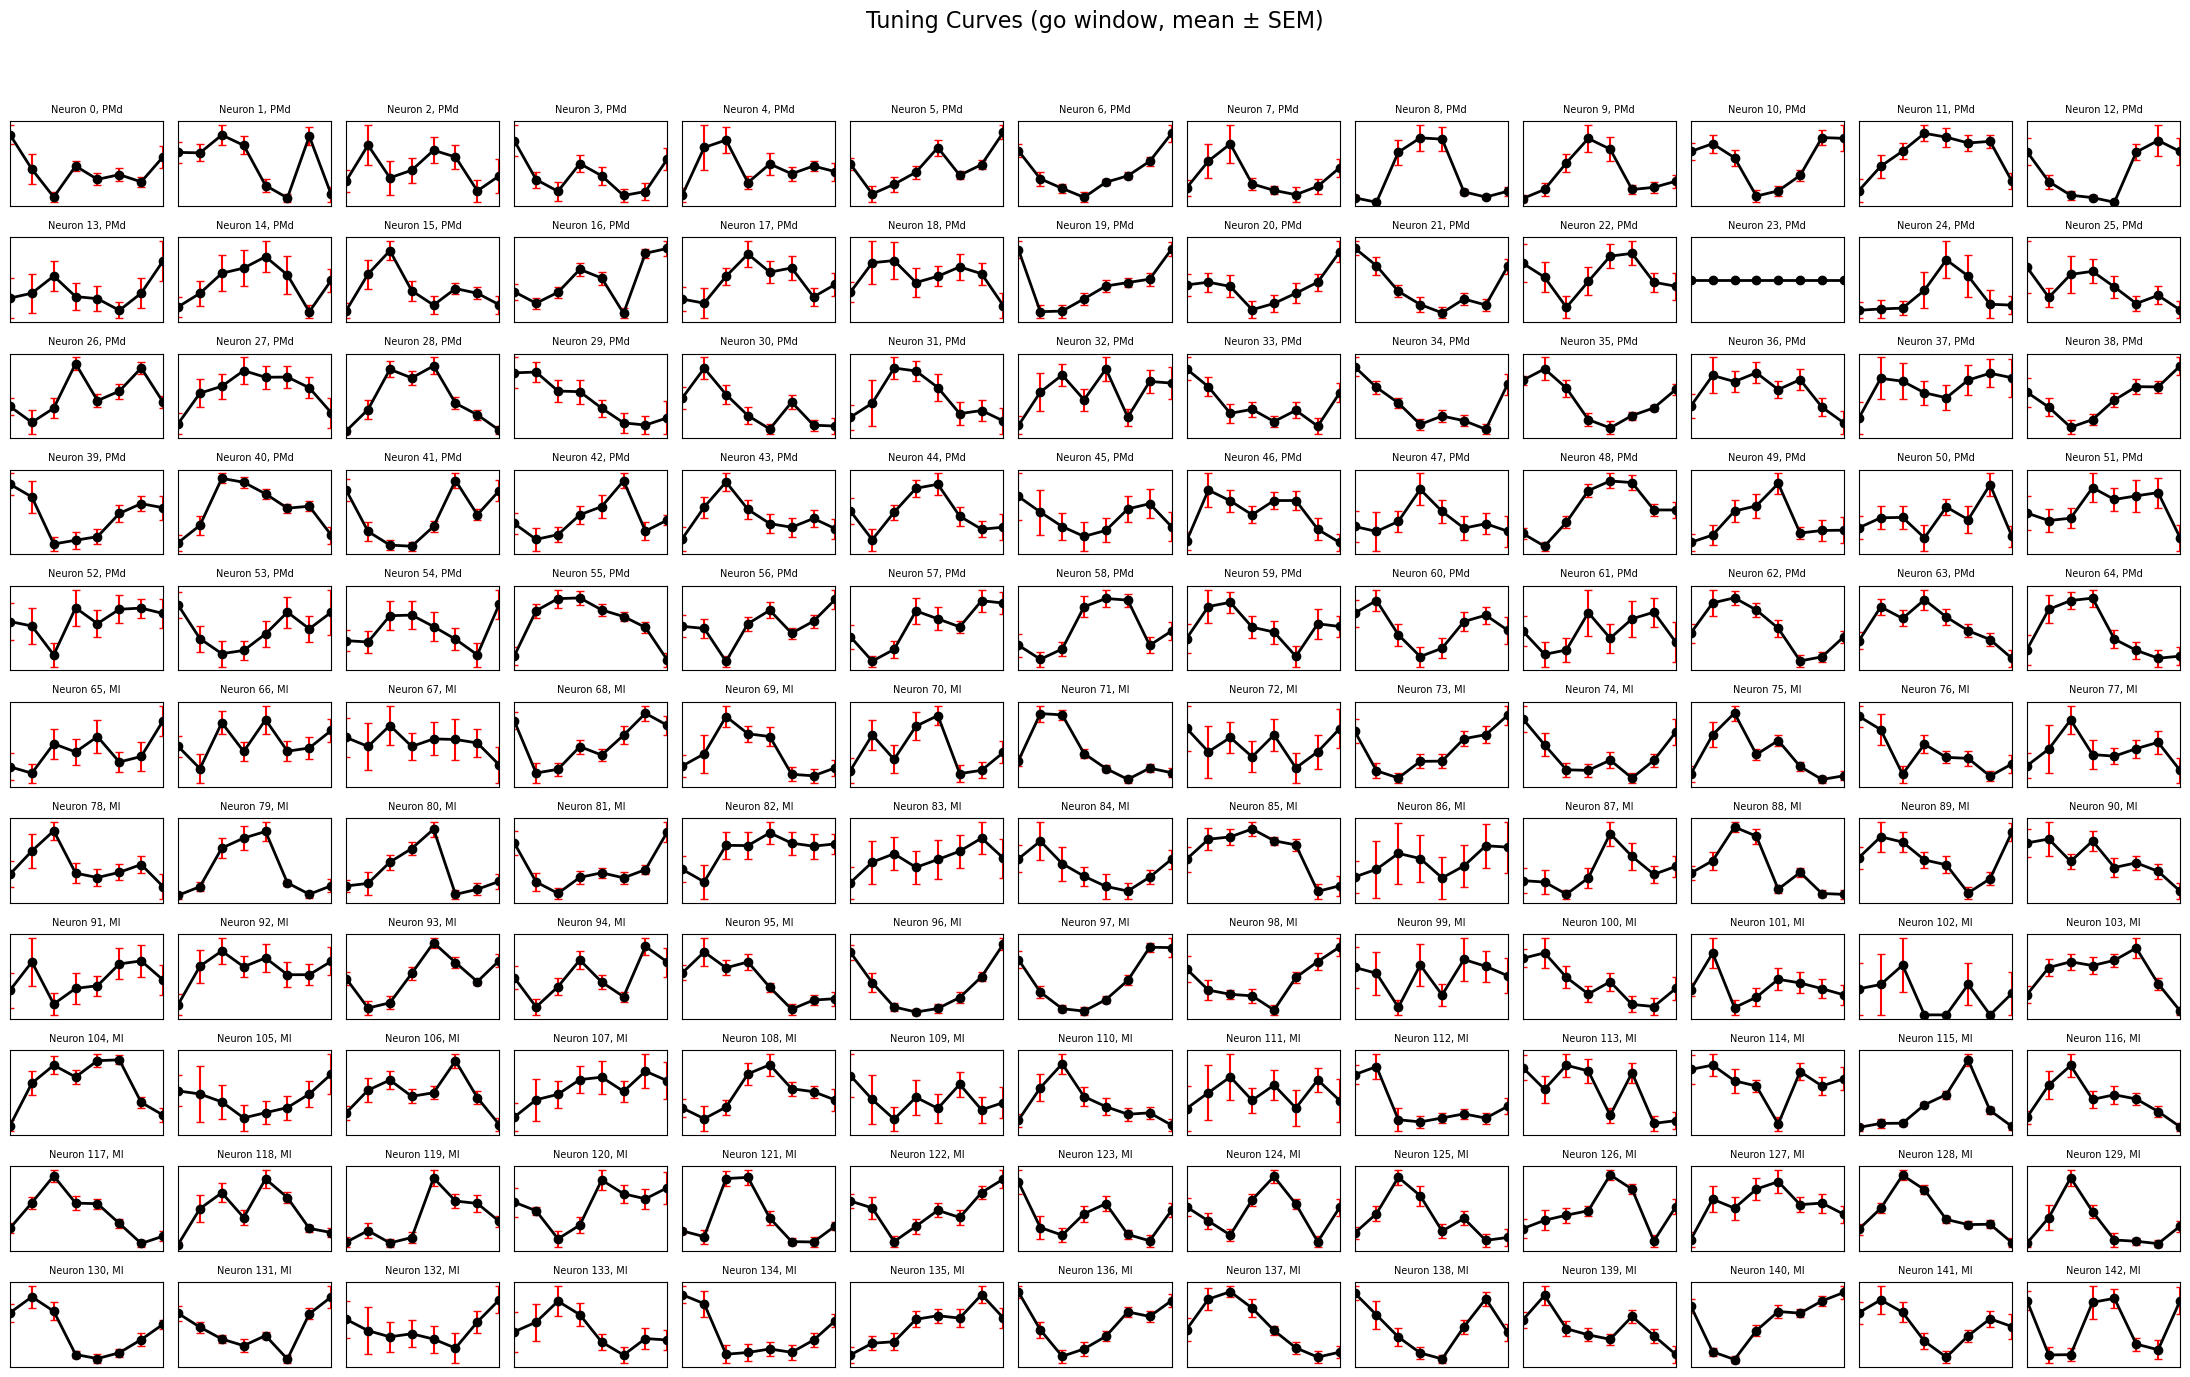

In [5]:
# =========================================================
# Step 1: Select a time window (instruction or go cue aligned)
# =========================================================
window = "go" # or instruction
motor_cortex_window = motor_cortex[motor_cortex["window"] == window]

# =========================================================
# Step 2: Group data by (cell_id, direction) and compute:
#         - mean spike count
#         - standard deviation
#         - SEM (standard error of the mean)
# =========================================================
grouped = motor_cortex_window.groupby(["cell_id", "direction"])
summary = grouped.agg(
    mean_spike=("spike_count", "mean"),
    std_spike=("spike_count", "std"),
    n=("spike_count", "count")
).reset_index()
summary["sem_spike"] = summary["std_spike"] / np.sqrt(summary["n"])

# =========================================================
# Step 3: Prepare axes and metadata
#         - directions = movement angles (e.g. 0°–360°)
#         - cell_ids   = neuron indices (0 to 142)
#         - brain area lookup for each neuron
# =========================================================
directions = np.sort(motor_cortex["direction"].unique())
cell_ids = np.sort(motor_cortex["cell_id"].unique())
cell_area_map = motor_cortex.drop_duplicates("cell_id").set_index("cell_id")["brain_area"].to_dict()

# =========================================================
# Step 4: Plot each neuron’s tuning curve
#         - x-axis = direction
#         - y-axis = spike count (mean ± SEM)
#         - black lines, red error bars
# =========================================================
fig, axes = plt.subplots(11, 13, figsize=(22, 14))
axes = axes.flatten()

for i, cell_id in enumerate(cell_ids):
    ax = axes[i]
    cell_data = summary[summary["cell_id"] == cell_id]

    # Align direction values
    means = [cell_data[cell_data["direction"] == d]["mean_spike"].values[0] if d in cell_data["direction"].values else np.nan for d in directions]
    errors = [cell_data[cell_data["direction"] == d]["sem_spike"].values[0] if d in cell_data["direction"].values else np.nan for d in directions]

    # Plot tuning curve
    ax.errorbar(
        directions, means, yerr=errors,
        fmt='-o', linewidth=2, color='black',
        ecolor='red', elinewidth=1.5, capsize=3
    )
    brain_area = cell_area_map.get(cell_id, "Unknown")
    ax.set_title(f"Neuron {cell_id}, {brain_area}", fontsize=7)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlim(directions.min(), directions.max())

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

# Title and layout
fig.suptitle(f"Tuning Curves ({window} window, mean ± SEM)", fontsize=16)
fig.patch.set_facecolor("white")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


/Users/sspivack/anaconda3/lib/python3.11/site-packages/scipy/optimize/_minpack_py.py:1010: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


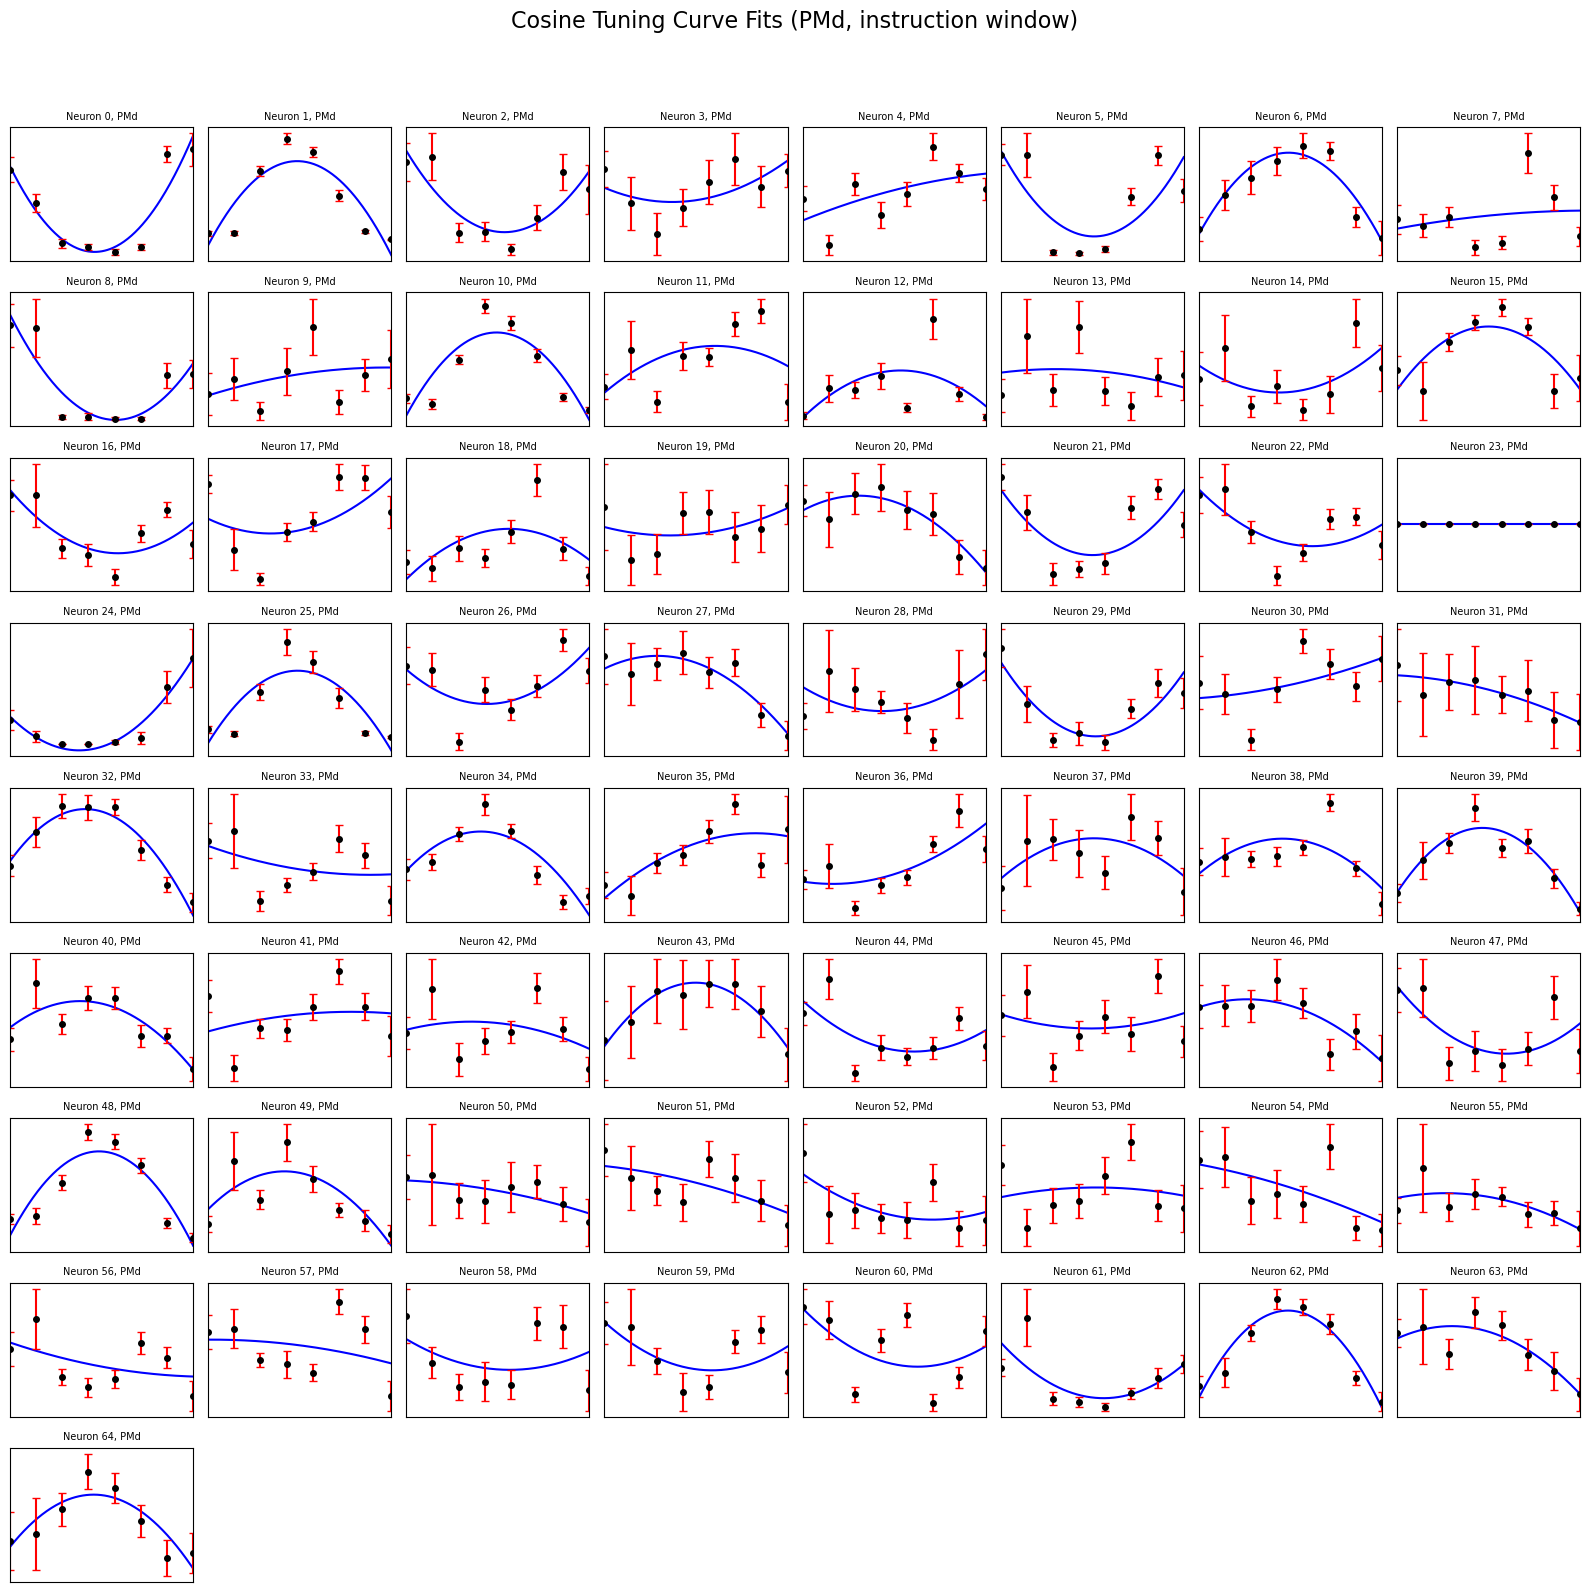

In [6]:
# ============================================================================
# Step 5: Fit cosine tuning curves to each neuron
# ============================================================================

# --- Cosine tuning function ---
def cosine_tuning(theta_deg, b, k, theta_pref_deg):
    theta_rad = np.deg2rad(theta_deg)
    theta_pref_rad = np.deg2rad(theta_pref_deg)
    return b + k * np.cos(theta_rad - theta_pref_rad)

# --- Set brain area to plot ---
selected_area = "PMd"

# --- Filter to selected window and brain area ---
window = "instruction"
motor_cortex_window = motor_cortex[
    (motor_cortex["window"] == window) &
    (motor_cortex["brain_area"] == selected_area)
]

# --- Recalculate summary stats just for this area ---
grouped = motor_cortex_window.groupby(["cell_id", "direction"])
summary = grouped.agg(
    mean_spike=("spike_count", "mean"),
    std_spike=("spike_count", "std"),
    n=("spike_count", "count")
).reset_index()
summary["sem_spike"] = summary["std_spike"] / np.sqrt(summary["n"])

# --- Setup ---
directions = np.sort(motor_cortex["direction"].unique())
cell_ids = np.sort(motor_cortex_window["cell_id"].unique())
cell_area_map = motor_cortex_window.drop_duplicates("cell_id").set_index("cell_id")["brain_area"].to_dict()

# --- Dynamically size the subplot grid ---
n_cells = len(cell_ids)
n_cols = 8
n_rows = math.ceil(n_cells / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(2 * n_cols, 1.8 * n_rows))
axes = axes.flatten()

# --- Fit and plot each neuron ---
for i, cell_id in enumerate(cell_ids):
    ax = axes[i]
    cell_data = summary[summary["cell_id"] == cell_id]

    # Extract x, y, error
    x = directions
    y = np.array([cell_data[cell_data["direction"] == d]["mean_spike"].values[0] if d in cell_data["direction"].values else np.nan for d in directions])
    yerr = np.array([cell_data[cell_data["direction"] == d]["sem_spike"].values[0] if d in cell_data["direction"].values else np.nan for d in directions])

    # Fit only if no NaNs
    if not np.isnan(y).any():
        try:
            guess = [np.mean(y), (np.max(y) - np.min(y)) / 2, x[np.argmax(y)]]
            popt, _ = curve_fit(cosine_tuning, x, y, p0=guess)
            fit_x = np.linspace(x.min(), x.max(), 200)
            fit_y = cosine_tuning(fit_x, *popt)
            ax.plot(fit_x, fit_y, color='blue', linewidth=1.5)
        except RuntimeError:
            pass  # Skip if fit fails

    # Plot original data (mean ± SEM)
    ax.errorbar(x, y, yerr=yerr, fmt='o', color='black', ecolor='red', capsize=3, markersize=4)
    brain_area = cell_area_map.get(cell_id, "Unknown")
    ax.set_title(f"Neuron {cell_id}, {brain_area}", fontsize=7)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlim(x.min(), x.max())

# Hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

fig.suptitle(f"Cosine Tuning Curve Fits ({selected_area}, {window} window)", fontsize=16)
fig.patch.set_facecolor("white")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [7]:
# =========================================================
# Step 6 Population Vector per Trial
# =========================================================

# --- User parameters ---
selected_area = "MI"
selected_window = "go"

# --- Filter dataset ---
df = motor_cortex[
    (motor_cortex["brain_area"] == selected_area) &
    (motor_cortex["window"] == selected_window)
].copy()

# --- Compute mean spike rate per neuron & direction (for tuning) ---
tuning = (
    df.groupby(["cell_id", "direction"])
    .agg(mean_spike=("spike_count", "mean"))
    .reset_index()
)

# --- Preferred and baseline firing ---
preferred_dirs = (
    tuning.loc[tuning.groupby("cell_id")["mean_spike"].idxmax(), ["cell_id", "direction"]]
    .rename(columns={"direction": "preferred_direction"})
)
baseline = (
    tuning.groupby("cell_id")["mean_spike"]
    .min()
    .rename("baseline")
    .reset_index()
)

# --- Merge into df ---
df = df.merge(preferred_dirs, on="cell_id", how="left").merge(baseline, on="cell_id", how="left")

# --- Convert to radians ---
n_dirs = df["direction"].nunique()
df["theta_move"] = np.deg2rad(df["direction"] * (360 / n_dirs))
df["theta_pref"] = np.deg2rad(df["preferred_direction"] * (360 / n_dirs))

# --- Compute weighted contributions ---
df["weight"] = df["spike_count"] - df["baseline"]
df["vx"] = df["weight"] * np.cos(df["theta_pref"])
df["vy"] = df["weight"] * np.sin(df["theta_pref"])

# --- Sum to get population vector per trial ---
pop_vectors = (
    df.groupby("trial_id")
    .agg(
        px=("vx", "sum"),
        py=("vy", "sum"),
        target_dir=("direction", "first")
    )
    .reset_index()
)

# --- Compute magnitude + decoded direction ---
pop_vectors["magnitude"] = np.sqrt(pop_vectors["px"]**2 + pop_vectors["py"]**2)
pop_vectors["decoded_dir_rad"] = np.arctan2(pop_vectors["py"], pop_vectors["px"])
pop_vectors["decoded_dir_deg"] = np.degrees(pop_vectors["decoded_dir_rad"]) % 360

# --- Map direction integers (1–8) to evenly spaced degrees (0–315) ---
dir_map = {i: (i - 1) * (360 / n_dirs) for i in sorted(df["direction"].unique())}
pop_vectors["target_dir_deg"] = pop_vectors["target_dir"].map(dir_map)

# --- Convert decoded direction (deg) back to discrete 1–8 bins ---
def angle_to_dir_idx(angle_deg):
    angle_deg = angle_deg % 360
    bin_centers = np.array([(i - 1) * (360 / n_dirs) for i in range(1, n_dirs + 1)])
    diffs = np.abs(bin_centers - angle_deg)
    return int(np.argmin(diffs)) + 1

pop_vectors["decoded_category"] = pop_vectors["decoded_dir_deg"].apply(angle_to_dir_idx)
pop_vectors["target_category"] = pop_vectors["target_dir"]

# --- Final DataFrame ---
population_df = pop_vectors[[
    "trial_id", "px", "py", "magnitude",
    "decoded_dir_deg", "decoded_category",
    "target_dir_deg", "target_category"
]].sort_values("trial_id").reset_index(drop=True)


In [8]:
population_df

,trial_id,px,py,magnitude,decoded_dir_deg,decoded_category,target_dir_deg,target_category
0,0,-150.073539,149.562256,211.874811,135.097766,4,90.0,3
1,1,-37.543055,-5.009857,37.875845,187.600816,5,180.0,5
2,2,-39.028337,7.990143,39.837839,168.429902,5,180.0,5
3,3,57.347818,150.437365,160.997431,69.13279,3,45.0,2
4,4,17.368633,-46.294129,49.445078,290.565088,7,225.0,6
...,...,...,...,...,...,...,...,...
153,153,-5.309037,208.993714,209.061135,91.455163,3,45.0,2
154,154,-58.756259,-54.950983,80.448172,223.08328,6,180.0,5
155,155,-35.19991,-11.394634,36.998261,197.93739,5,270.0,7
156,156,37.871158,124.771889,130.392672,73.115741,3,0.0,1


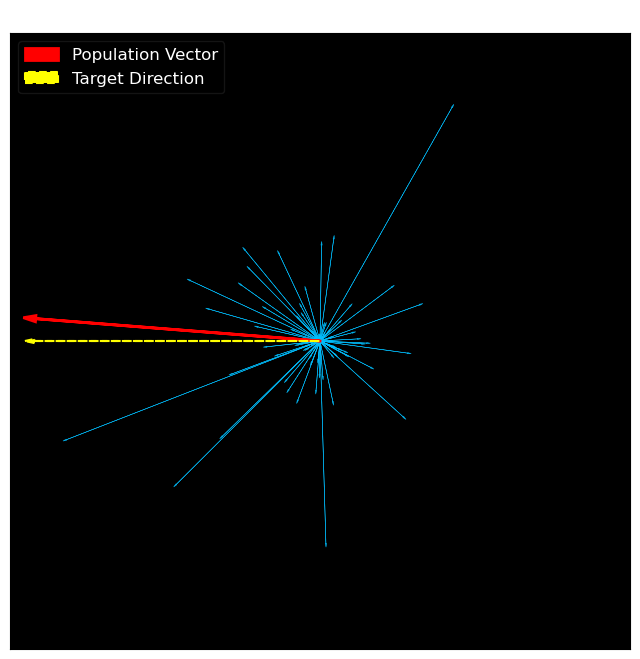

In [9]:
# =========================================================
# Step 7 Plot Population Vector per Trial
# =========================================================

# --- Select trial ID ---
trial_id_to_plot = 2

# --- Filter data for selected trial, area, and window ---
selected_area = "MI"
selected_window = "go"
trial_df = motor_cortex[
    (motor_cortex["brain_area"] == selected_area) &
    (motor_cortex["window"] == selected_window) &
    (motor_cortex["trial_id"] == trial_id_to_plot)
].copy()

# --- Compute mean spike per neuron x direction ---
n_dirs = motor_cortex["direction"].nunique()
angle_per_bin = 360 / n_dirs
tuning = (
    motor_cortex[
        (motor_cortex["brain_area"] == selected_area) &
        (motor_cortex["window"] == selected_window)
    ]
    .groupby(["cell_id", "direction"])
    .agg(mean_spike=("spike_count", "mean"))
    .reset_index()
)

# --- Fit cosine to get continuous preferred angle ---
def fit_cosine_for_cell(cell_data):
    x = cell_data["direction"].values * angle_per_bin
    y = cell_data["mean_spike"].values
    if len(x) < 3 or np.any(np.isnan(y)):
        return np.nan
    try:
        guess = [np.mean(y), (np.max(y) - np.min(y)) / 2, x[np.argmax(y)]]
        popt, _ = curve_fit(lambda theta, b, k, theta_pref: b + k * np.cos(np.deg2rad(theta - theta_pref)), x, y, p0=guess)
        return popt[2] % 360
    except:
        return np.nan

pref_angles = (
    tuning.groupby("cell_id")[["direction", "mean_spike"]]
    .apply(fit_cosine_for_cell)
    .dropna()
    .rename("theta_pref_deg")
    .reset_index()
)

baseline = (
    tuning.groupby("cell_id")["mean_spike"]
    .min()
    .rename("baseline")
    .reset_index()
)

# --- Merge into trial dataframe ---
trial_df = trial_df.merge(pref_angles, on="cell_id", how="inner").merge(baseline, on="cell_id", how="left")
trial_df["theta_pref_rad"] = np.deg2rad(trial_df["theta_pref_deg"])
trial_df["weight"] = trial_df["spike_count"] - trial_df["baseline"]

# --- Scale neuron vectors (longer + thinner) ---
blue_scale = 8.0
trial_df["vx"] = blue_scale * trial_df["weight"] * np.cos(trial_df["theta_pref_rad"])
trial_df["vy"] = blue_scale * trial_df["weight"] * np.sin(trial_df["theta_pref_rad"])

# --- Population vector ---
px = trial_df["vx"].sum()
py = trial_df["vy"].sum()
pop_angle = np.arctan2(py, px)

# --- Target direction (yellow) ---
target_bin = trial_df["direction"].iloc[0]
target_theta_deg = (target_bin - 1) * angle_per_bin
target_theta_rad = np.deg2rad(target_theta_deg)

# --- Set red/yellow to fixed long length for plotting ---
fixed_len = 230  # ensures both red and yellow reach plot edge
px_plot = fixed_len * np.cos(pop_angle)
py_plot = fixed_len * np.sin(pop_angle)
tx_plot = fixed_len * np.cos(target_theta_rad)
ty_plot = fixed_len * np.sin(target_theta_rad)

# --- Plot ---
plt.figure(figsize=(8, 8))
ax = plt.gca()
ax.set_facecolor("black")
plt.axis("equal")
plt.xticks([])
plt.yticks([])
plt.xlim(-250, 250)
plt.ylim(-250, 250)

# Blue neuron vectors — longer, thinner
for _, row in trial_df.iterrows():
    plt.arrow(0, 0, row["vx"], row["vy"],
              color='deepskyblue', alpha=0.85,
              head_width=1.0, head_length=3, linewidth=0.4)

# Red: population vector (fixed length)
plt.arrow(0, 0, px_plot, py_plot,
          color='red', linewidth=2,
          head_width=5, head_length=10,
          label="Population Vector")

# Yellow: target direction (fixed length)
plt.arrow(0, 0, tx_plot, ty_plot,
          color='yellow', linewidth=1.5, linestyle='--',
          head_width=3.5, head_length=8,
          label="Target Direction")

# Legend with white text
legend = plt.legend(loc='upper left', facecolor='black', framealpha=0.1, fontsize=12)
for text in legend.get_texts():
    text.set_color("white")

plt.title(f"Trial {trial_id_to_plot}: Population Vector Decoding", color='white', fontsize=14)
plt.show()


In [10]:
# =========================================================
# Step 8 Plot Population Vector per Trial (Animated)
# =========================================================

# --- Set up temporary frame directory ---
frame_dir = "popvec_temp_frames"
os.makedirs(frame_dir, exist_ok=True)
gif_path = "population_vector_animation.gif"

# --- Generate frames ---
with imageio.get_writer(gif_path, mode='I', duration=0.15) as writer:
    for i in tqdm(range(len(population_df)), desc="Generating GIF frames"):

        trial_id_to_plot = i
        selected_area = "MI"
        selected_window = "go"

        trial_df = motor_cortex[
            (motor_cortex["brain_area"] == selected_area) &
            (motor_cortex["window"] == selected_window) &
            (motor_cortex["trial_id"] == trial_id_to_plot)
        ].copy()

        n_dirs = motor_cortex["direction"].nunique()
        angle_per_bin = 360 / n_dirs

        tuning = (
            motor_cortex[
                (motor_cortex["brain_area"] == selected_area) &
                (motor_cortex["window"] == selected_window)
            ]
            .groupby(["cell_id", "direction"])
            .agg(mean_spike=("spike_count", "mean"))
            .reset_index()
        )

        def fit_cosine_for_cell(cell_data):
            x = cell_data["direction"].values * angle_per_bin
            y = cell_data["mean_spike"].values
            if len(x) < 3 or np.any(np.isnan(y)):
                return np.nan
            try:
                guess = [np.mean(y), (np.max(y) - np.min(y)) / 2, x[np.argmax(y)]]
                popt, _ = curve_fit(lambda theta, b, k, theta_pref: b + k * np.cos(np.deg2rad(theta - theta_pref)), x, y, p0=guess)
                return popt[2] % 360
            except:
                return np.nan

        pref_angles = (
            tuning.groupby("cell_id")[["direction", "mean_spike"]]
            .apply(fit_cosine_for_cell)
            .dropna()
            .rename("theta_pref_deg")
            .reset_index()
        )

        baseline = (
            tuning.groupby("cell_id")["mean_spike"]
            .min()
            .rename("baseline")
            .reset_index()
        )

        trial_df = trial_df.merge(pref_angles, on="cell_id", how="inner").merge(baseline, on="cell_id", how="left")
        trial_df["theta_pref_rad"] = np.deg2rad(trial_df["theta_pref_deg"])
        trial_df["weight"] = trial_df["spike_count"] - trial_df["baseline"]

        blue_scale = 8.0
        trial_df["vx"] = blue_scale * trial_df["weight"] * np.cos(trial_df["theta_pref_rad"])
        trial_df["vy"] = blue_scale * trial_df["weight"] * np.sin(trial_df["theta_pref_rad"])

        px = trial_df["vx"].sum()
        py = trial_df["vy"].sum()
        pop_angle = np.arctan2(py, px)

        target_bin = trial_df["direction"].iloc[0]
        target_theta_deg = (target_bin - 1) * angle_per_bin
        target_theta_rad = np.deg2rad(target_theta_deg)

        fixed_len = 230
        px_plot = fixed_len * np.cos(pop_angle)
        py_plot = fixed_len * np.sin(pop_angle)
        tx_plot = fixed_len * np.cos(target_theta_rad)
        ty_plot = fixed_len * np.sin(target_theta_rad)

        # --- Plot ---
        fig = plt.figure(figsize=(6, 6))
        ax = plt.gca()
        ax.set_facecolor("black")
        plt.axis("equal")
        plt.xticks([])
        plt.yticks([])
        plt.xlim(-250, 250)
        plt.ylim(-250, 250)

        for _, row in trial_df.iterrows():
            plt.arrow(0, 0, row["vx"], row["vy"],
                      color='deepskyblue', alpha=0.85,
                      head_width=1.0, head_length=3, linewidth=0.4)

        plt.arrow(0, 0, px_plot, py_plot,
                  color='red', linewidth=2,
                  head_width=5, head_length=10,
                  label="Population Vector")

        plt.arrow(0, 0, tx_plot, ty_plot,
                  color='yellow', linewidth=1.5, linestyle='--',
                  head_width=3.5, head_length=8,
                  label="Target Direction")

        legend = plt.legend(loc='upper left', facecolor='black', framealpha=0.1, fontsize=10)
        for text in legend.get_texts():
            text.set_color("white")

        plt.title(f"Trial {trial_id_to_plot}", color='white', fontsize=12)

        frame_path = os.path.join(frame_dir, f"frame_{i:03d}.png")
        plt.savefig(frame_path, dpi=100, bbox_inches='tight', pad_inches=0.05)
        plt.close(fig)

        # Append frame to GIF
        writer.append_data(imageio.imread(frame_path))

# --- Delete frames ---
shutil.rmtree(frame_dir)


Generating GIF frames: 100%|██████████████████| 158/158 [00:20<00:00,  7.82it/s]
